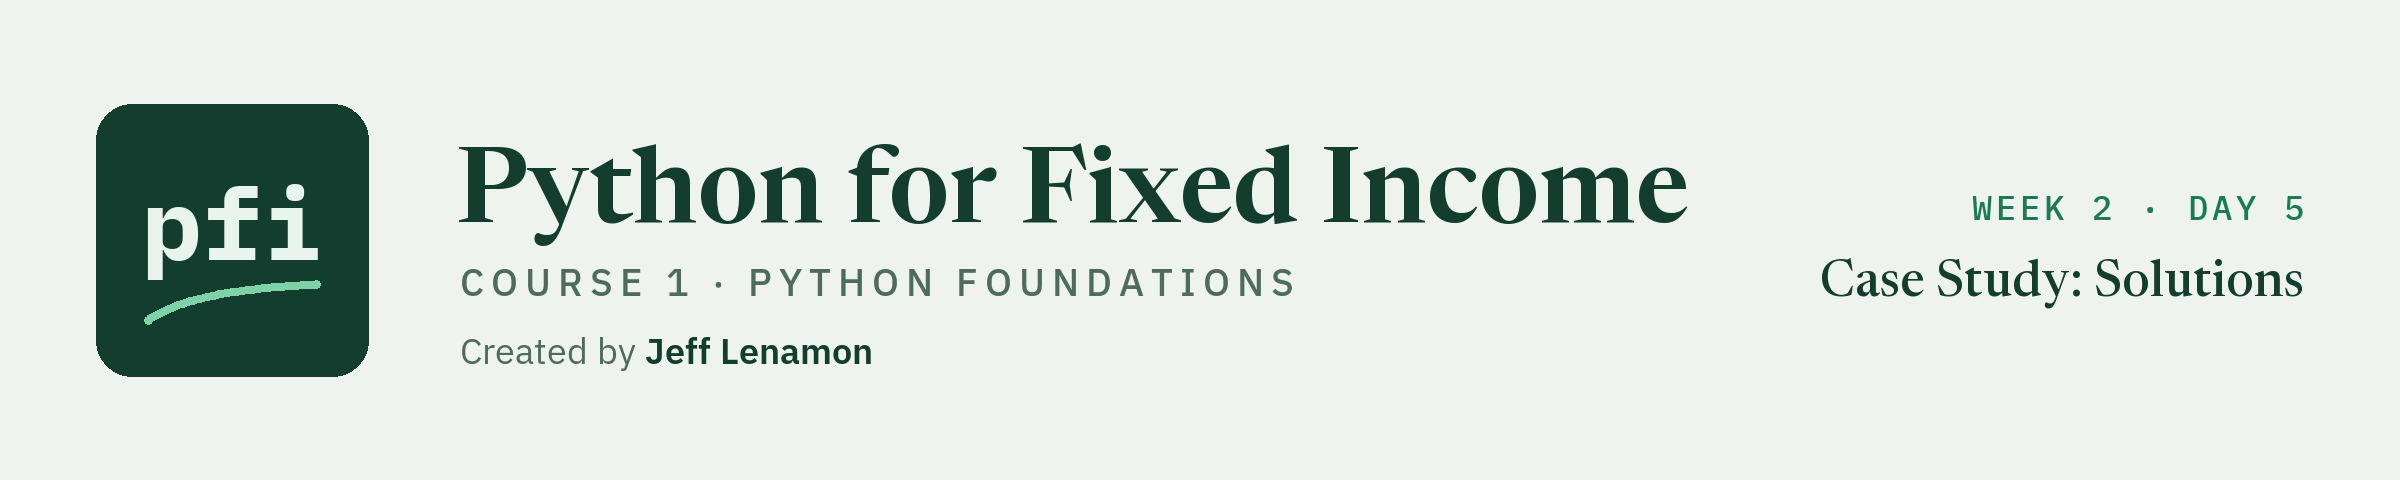

# Case Study: Joining the Tables - Solutions

Week 2. Worked answers to the exercises. Try each one yourself first.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course1_python_foundations/week2/day5/10_case_study_joining_the_tables_solutions.ipynb)

## Exercises

The desk has follow-up questions. Each one is answered from the joined book, and none repeats a question from the lesson. The issuers are invented, and every answer describes the data and is not a view.

Replace each `...` with your own code, then run the check cell under it. Worked answers are in the solutions notebook in this folder.

Run the next cell first. It imports pandas, loads fresh copies of the tables, rebuilds the joined book as `book` with the `value` and `coupon_income` columns, and defines `check`, a small function that marks your answers. It prints the shape of the book and its total face: (200, 15) and 489,000,000. As in the lesson, `value` is value at the clean price, before accrued interest.

In [1]:
import os

import pandas as pd


def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    if answer is ...:
        print(label + ': not attempted yet')
        return
    if isinstance(expected, list):
        # a list of values: the same values in the same order
        correct = list(answer) == expected
    elif isinstance(expected, float):
        # single numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 0.000001
    else:
        correct = answer == expected
    if correct:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)


# fresh copies of the tables. In Colab they are read from GitHub.
if os.path.exists('../../../data/positions.csv'):
    data_folder = '../../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

positions = pd.read_csv(data_folder + 'positions.csv')
issuers = pd.read_csv(data_folder + 'issuers.csv')
ratings = pd.read_csv(data_folder + 'ratings.csv')
benchmark = pd.read_csv(data_folder + 'benchmark.csv')

# the joined book, rebuilt: two left merges and two prepared columns
book = pd.merge(positions, issuers, on='ticker', how='left')
book = pd.merge(book, ratings, on='rating', how='left')
book['value'] = book['par_held'] * book['price'] / 100
book['coupon_income'] = book['par_held'] * book['coupon'] / 100

print(book.shape, book['par_held'].sum())

(200, 15) 489000000


### Exercise 1

Q. How many bonds does the book hold in the Utilities and Transportation sectors together, and how much face? Store the answers in **ex1_bonds** and **ex1_face**. Use `isin()` with a list of the two sector names.

In [2]:
# the rows of the book in either sector
two_sectors = book[book['sector'].isin(['Utilities', 'Transportation'])]

ex1_bonds = len(two_sectors)
ex1_face = two_sectors['par_held'].sum()

print('Bonds:', ex1_bonds)
print('Face:', ex1_face)

Bonds: 32
Face: 79250000


* 32 bonds with 79,250,000 of face. The lesson's sector table gave 12 bonds in Utilities and 20 in Transportation, and 12 plus 20 is 32.

In [3]:
check('Exercise 1 bonds', ex1_bonds, 32)
check('Exercise 1 face', ex1_face, 79250000)

Exercise 1 bonds: correct
Exercise 1 face: correct


### Exercise 2

Q. What is the average price of the book, simple and value-weighted? Round each to 2 decimal places and store them in **ex2_simple** and **ex2_weighted**. Is the weighted average the higher of the two? Store True or False in **ex2_weighted_higher**.

In [4]:
simple_price = book['price'].mean()

# a sum of price times value, divided by the sum of value
weighted_price = (book['price'] * book['value']).sum() / book['value'].sum()

ex2_simple = round(simple_price, 2)
ex2_weighted = round(weighted_price, 2)
ex2_weighted_higher = weighted_price > simple_price

print('Simple average price:', ex2_simple)
print('Value-weighted average price:', ex2_weighted)
print('Weighted is higher:', ex2_weighted_higher)

Simple average price: 98.83
Value-weighted average price: 99.33
Weighted is higher: True


* 98.83 simple and 99.33 value-weighted. The weighted average is half a point higher.
* The weight here is the value, and the value is face times price. So a higher-priced bond gets a larger weight for the same face, which pulls a value-weighted average price up. The lesson's 98.778 per 100 of face was the same average weighted by face.

In [5]:
check('Exercise 2 simple', ex2_simple, 98.83)
check('Exercise 2 weighted', ex2_weighted, 99.33)
check('Exercise 2 weighted higher', ex2_weighted_higher, True)

Exercise 2 simple: correct
Exercise 2 weighted: correct
Exercise 2 weighted higher: correct


### Exercise 3

Q. Which three sectors pay the most annual coupon income, largest first? Store their names as a list in **ex3_top_three**. How much does the largest of them pay? Store it in **ex3_top_income**.

In [6]:
# coupon income added up within each sector, largest first
income_by_sector = book.groupby('sector')['coupon_income'].sum()
top_three = income_by_sector.sort_values(ascending=False).head(3)
print(top_three)

# the index of the result holds the sector names
ex3_top_three = top_three.index.tolist()
ex3_top_income = top_three.iloc[0]

sector
Materials     4205937.5
Financials    3881250.0
Consumer      3545312.5
Name: coupon_income, dtype: float64


* Materials, Financials, and Consumer, in that order. Materials pays 4,205,937.5 a year in coupons. They are the same three sectors, in the same order, that hold the most value in the lesson.

In [7]:
check('Exercise 3 top three', ex3_top_three, ['Materials', 'Financials', 'Consumer'])
check('Exercise 3 top income', ex3_top_income, 4205937.5)

Exercise 3 top three: correct
Exercise 3 top income: correct


### Exercise 4

The lesson's value left out accrued interest because the positions file does not carry it. The benchmark file does: its `accrued` column is accrued interest per 100 of face, and it has one row per `cusip`.

Q. Merge the book with the `cusip` and `accrued` columns of the benchmark, keeping every row of the book. How many rows does the result have? What is the accrued interest of the whole book in dollars, and what is the value with accrued interest added? Store the answers in **ex4_rows**, **ex4_accrued**, and **ex4_full_value**, the last two rounded to 2 decimal places.

In [8]:
# only the key and the one column wanted, so no other benchmark column comes along
with_accrued = pd.merge(book, benchmark[['cusip', 'accrued']], on='cusip', how='left')

# the check: rows and face, before and after, and no gaps in the new column
print('Rows before:', book.shape[0], ' after:', with_accrued.shape[0])
print('Face before:', book['par_held'].sum(), ' after:', with_accrued['par_held'].sum())
print('Missing accrued:', with_accrued['accrued'].isna().sum())

# accrued is per 100 of face, like the price
accrued_dollars = with_accrued['par_held'] * with_accrued['accrued'] / 100

ex4_rows = with_accrued.shape[0]
ex4_accrued = round(accrued_dollars.sum(), 2)
ex4_full_value = round(with_accrued['value'].sum() + accrued_dollars.sum(), 2)

print('Accrued interest:', ex4_accrued)
print('Value with accrued interest:', ex4_full_value)

Rows before: 200  after: 200
Face before: 489000000  after: 489000000
Missing accrued: 0
Accrued interest: 7794985.0
Value with accrued interest: 490819215.0


* 200 rows before and after, the same face, and no missing accrued: every CUSIP in the book was found in the benchmark, once.
* Accrued interest is 7,794,985. Added to the 483,024,230 at the clean price it gives 490,819,215, the value including accrued interest.
* Selecting `benchmark[['cusip', 'accrued']]` matters. The benchmark also has `ticker`, `price`, and other columns the book already holds, and merging the whole table would bring them in a second time under changed names.

In [9]:
check('Exercise 4 rows', ex4_rows, 200)
check('Exercise 4 accrued', ex4_accrued, 7794985.0)
check('Exercise 4 full value', ex4_full_value, 490819215.0)

Exercise 4 rows: correct
Exercise 4 accrued: correct
Exercise 4 full value: correct


### Exercise 5: AI check

You ask an AI assistant how many bonds the desk holds in the Utilities and Transportation sectors. It gives you the code below. It was written for this course in the style of an AI assistant's answer. It contains one bug.

Q. Read the code before you run it. What number do you expect? You worked it out yourself in Exercise 1. Then run the code. Does it agree with you?

* The answer from Exercise 1 is 32. The original code printed 47, with no error.
* The bug was the order of the tables in the first merge. The code wrote `pd.merge(issuers, positions, on='ticker', how='left')`, which makes the issuers the left table. A left merge keeps every row of the left table, so all 150 issuers were kept, including the 35 with no position. Each of those became a row with a sector and no bond.
* The joined table had 235 rows, not 200. Fifteen of the 35 extra rows are issuers in Utilities or Transportation, and `len()` counted them as bonds: 32 plus 15 is 47.
* The check from the lesson catches it in one line: the row count after the merge should be 200. The fix is to start from the positions, the table whose rows are the bonds.

In [10]:
# the positions are the left table: one row per bond held
joined = pd.merge(positions, issuers, on='ticker', how='left')
joined = pd.merge(joined, ratings, on='rating', how='left')
print('Rows:', joined.shape[0])

# the rows in the two sectors
two_sectors = joined[joined['sector'].isin(['Utilities', 'Transportation'])]
ex5_bonds = len(two_sectors)

print('Bonds in Utilities and Transportation:', ex5_bonds)

Rows: 200
Bonds in Utilities and Transportation: 32


In [11]:
check('Exercise 5 bonds', ex5_bonds, 32)

Exercise 5 bonds: correct
